# 07 - Poređenje modela i zaključci

U ovoj svesci skupljamo rezultate svih prethodnih svezaka i odgovaramo na pitanja
iz naslova projekta:

1. koji model najbolje predviđa potražnju na satnom nivou
2. kako se isti modeli ponašaju na dnevnom nivou
3. da li se dve grupe korisnika, povremeni i registrovani, predviđaju različito
4. odakle dolazi sistematsko odstupanje koje smo videli kod svih modela

Sveska koristi sačuvane modele iz svezaka 03, 04 i 06 i tabele rezultata iz svezaka
05 i 06, pa je potrebno da sve prethodne sveske budu pokrenute.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import preprocessing
from sklearn import linear_model
from sklearn import ensemble
from sklearn import model_selection
from sklearn import metrics

from tensorflow.keras.models import load_model

np.random.seed(7)

# Učitavanje podataka i modela

In [2]:
sat = pd.read_csv('../data/hour.csv')
dan = pd.read_csv('../data/day.csv')

paket = joblib.load('../data/pripremljeno.joblib')

X = paket['X']
y = paket['y']
kolone = paket['kolone']

h_trening = paket['h_trening']
h_validacija = paket['h_validacija']
h_test = paket['h_test']

h_trening_validacija = h_trening | h_validacija

In [3]:
x_test = X[h_test]
y_test = y[h_test]
sat_test = sat[h_test]

print('test:', x_test.shape)

test: (8734, 52)


In [4]:
model_linear = joblib.load('../models/03_linearna_regresija.joblib')
scaler_linear = joblib.load('../models/03_scaler.joblib')

model_knn = joblib.load('../models/04_knn.joblib')
scaler_knn = joblib.load('../models/04_scaler.joblib')

model_forest = joblib.load('../models/04_slucajna_suma.joblib')

model_mreza = load_model('../models/06_mreza.keras')
scaler_mreza = joblib.load('../models/06_scaler.joblib')

In [5]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    mae = metrics.mean_absolute_error(y_stvarno, y_predvidjeno)
    rmse = np.sqrt(metrics.mean_squared_error(y_stvarno, y_predvidjeno))
    r2 = metrics.r2_score(y_stvarno, y_predvidjeno)
    odstupanje = np.mean(y_predvidjeno - y_stvarno)
    print('%-38s MAE %7.1f  RMSE %7.1f  R2 %6.3f  odstupanje %+8.1f'
          % (naziv, mae, rmse, r2, odstupanje))
    return {'model': naziv, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'odstupanje': odstupanje}

# Regresija na satnom nivou

Učitavamo tabelu iz sveske 06, u kojoj su rezultati svih regresionih modela na
skupu za testiranje, hronološka podela.

In [6]:
rezultati_sat = pd.read_csv('../models/06_rezultati.csv', index_col='model')
rezultati_sat.round(3)

,MAE,RMSE,R2,odstupanje
model,,,,
trivijalna osnova,108.516,157.051,0.435,-91.874
linearna regresija,110.178,158.026,0.428,-86.715
linearna regresija sa težinama,110.297,161.012,0.406,-88.132
k najbližih suseda,116.345,168.544,0.349,-102.667
slučajna šuma,92.986,129.738,0.614,-81.236
neuronska mreža,88.123,122.473,0.656,-82.386


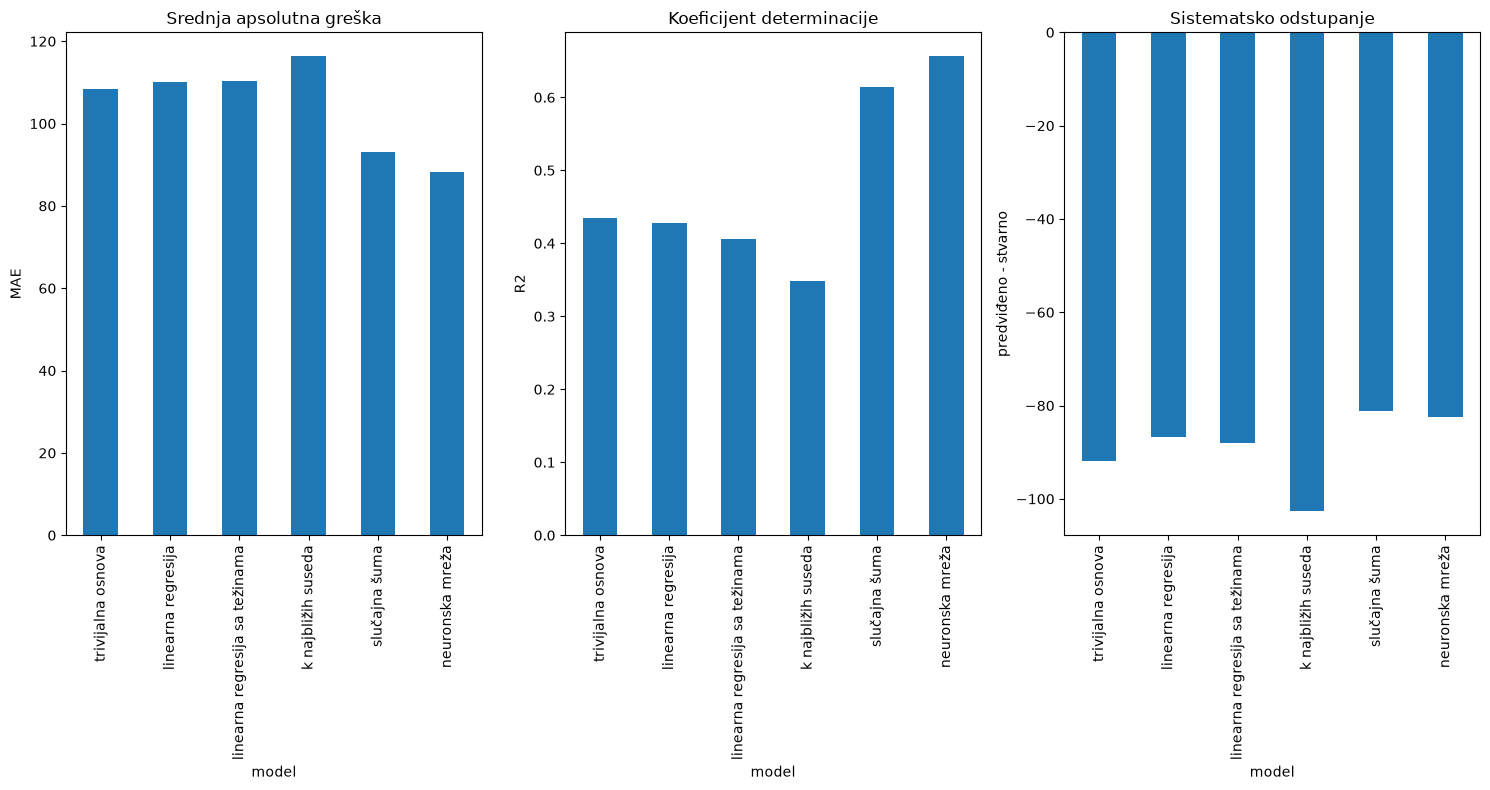

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 8))

rezultati_sat['MAE'].plot(kind='bar', ax=ax[0])
ax[0].set_title('Srednja apsolutna greška')
ax[0].set_ylabel('MAE')

rezultati_sat['R2'].plot(kind='bar', ax=ax[1])
ax[1].set_title('Koeficijent determinacije')
ax[1].set_ylabel('R2')

rezultati_sat['odstupanje'].plot(kind='bar', ax=ax[2])
ax[2].set_title('Sistematsko odstupanje')
ax[2].set_ylabel('predviđeno - stvarno')

plt.tight_layout()
plt.show()

Modeli se dele u dve grupe. Linearni modeli i metod najbližih suseda su lošiji od trivijalne osnove, dok su slučajna šuma i neuronska mreža bolji od nje. Najbolja je neuronska mreža, sa greškom od 88 bicikala po satu i koeficijentom determinacije 0.66.

Treći grafik pokazuje ono što je zajedničko svim modelima: svi potcenjuju potražnju za 80 do 100 bicikala po satu. Odstupanje se skoro ne menja od modela do modela, pa nije posledica izbora modela. 

Za dalju analizu su nam potrebna predviđanja modela na skupu za testiranje, pa ih
računamo ponovo iz sačuvanih modela.

In [8]:
predvidjanja = pd.DataFrame(index=sat_test.index)

predvidjanja['linearna regresija'] = model_linear.predict(scaler_linear.transform(x_test))
predvidjanja['k najbližih suseda'] = model_knn.predict(scaler_knn.transform(x_test))
predvidjanja['slučajna šuma'] = model_forest.predict(x_test)
predvidjanja['neuronska mreža'] = np.maximum(model_mreza.predict(scaler_mreza.transform(x_test), verbose=0).ravel(), 0)

In [9]:
for naziv in predvidjanja.columns:
    oceni(y_test, predvidjanja[naziv], naziv)

linearna regresija                     MAE   110.2  RMSE   158.0  R2  0.428  odstupanje    -86.7
k najbližih suseda                     MAE   116.3  RMSE   168.5  R2  0.349  odstupanje   -102.7
slučajna šuma                          MAE    93.0  RMSE   129.7  R2  0.614  odstupanje    -81.2
neuronska mreža                        MAE    88.1  RMSE   122.5  R2  0.656  odstupanje    -82.4


Vrednosti se poklapaju sa tabelom, dakle sačuvani modeli su ispravno učitani.

## Odstupanje po mesecima

Skup za testiranje pokriva celu 2012. godinu. Gledamo kako se sistematsko odstupanje
dva najbolja modela menja od meseca do meseca.

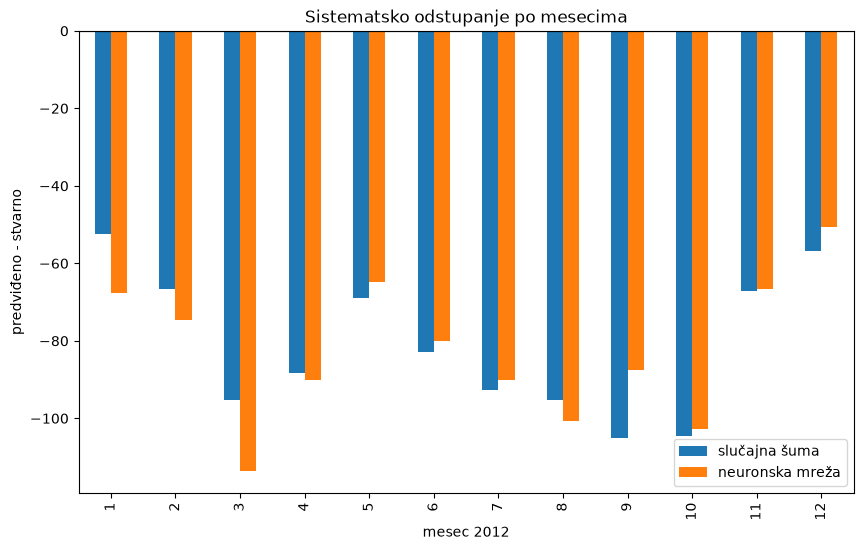

In [10]:
odstupanje_po_mesecu = pd.DataFrame({
    'slučajna šuma': predvidjanja['slučajna šuma'].values - y_test,
    'neuronska mreža': predvidjanja['neuronska mreža'].values - y_test
}, index=sat_test['mnth'].values).groupby(level=0).mean()

odstupanje_po_mesecu.plot(kind='bar', figsize=(10, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('mesec 2012')
plt.ylabel('predviđeno - stvarno')
plt.title('Sistematsko odstupanje po mesecima')
plt.show()

In [11]:
odstupanje_po_mesecu.round(1).T

,1,2,3,4,5,6,7,8,9,10,11,12
slučajna šuma,-52.5,-66.5,-95.2,-88.2,-68.8,-83.0,-92.6,-95.2,-105.0,-104.5,-67.0,-56.7
neuronska mreža,-67.7,-74.6,-113.6,-90.0,-64.8,-80.1,-90.0,-100.6,-87.5,-102.7,-66.5,-50.6


Apsolutno odstupanje zavisi i od nivoa potražnje, koja je leti veća, pa ga gledamo i relativno, u odnosu na stvarnu prosečnu potražnju u mesecu.

In [12]:
stvarno_po_mesecu = pd.Series(y_test, index=sat_test['mnth'].values).groupby(level=0).mean()

relativno_odstupanje = (100 * odstupanje_po_mesecu.div(stvarno_po_mesecu, axis=0)).round(1)
relativno_odstupanje.T

,1,2,3,4,5,6,7,8,9,10,11,12
slučajna šuma,-40.2,-44.6,-42.9,-36.4,-26.1,-29.5,-33.9,-33.0,-34.6,-37.2,-31.5,-34.0
neuronska mreža,-51.9,-50.0,-51.2,-37.1,-24.6,-28.4,-32.9,-34.9,-28.8,-36.6,-31.3,-30.3


Apsolutno odstupanje je najmanje u zimskim mesecima, januaru i decembru, između -50 i -70 bicikala, a najveće u martu i u jesen, oko -100 i više, kada je i potražnja najveća.

Relativna slika je drugačija: potcenjivanje je najveće od januara do marta, između 40 i 52 posto stvarne potražnje, a od maja pada na 25 do 37 posto. To se poklapa sa rastom sistema: prva četiri meseca 2012. imala su 1.8 do 2.5 puta veću potražnju nego isti meseci 2011, a od maja rast je oko 1.4 do 1.7 puta. Modeli obučeni na 2011. predviđaju nivo iz 2011, pa najviše promašuju tamo gde je skok između dve godine bio najveći.

# Klasifikacija nivoa opterećenja

In [13]:
rezultati_klasifikacija = pd.read_csv('../models/05_rezultati.csv', index_col='model')
rezultati_klasifikacija.round(3)

,tačnost,F1 makro
model,,
većinska klasa,0.217,0.119
osnova po satu i tipu dana,0.711,0.714
multinomijalna logistička regresija,0.698,0.687
slučajna šuma,0.722,0.711


Klasifikacija daje istu sliku kao regresija, samo u blažem obliku. Osnova po satu i tipu dana ima tačnost 0.71 i F1 meru 0.71, logistička regresija je ispod nje po obe mere, a slučajna šuma je iznad samo po tačnosti (0.72), dok je po F1 meri izjednačena sa osnovom.

# Dnevni nivo

Naslov projekta pominje i dnevni nivo. Dnevnu potražnju možemo predvideti na dva načina:

1. sabiranjem satnih predviđanja za svaki dan
2. obučavanjem modela direktno na dnevnim podacima iz fajla day.csv

Poredimo oba pristupa na istoj hronološkoj podeli, 2011. za obučavanje i 2012. za test.

## Zbir satnih predviđanja

In [14]:
dnevno = predvidjanja.copy()
dnevno['stvarno'] = y_test
dnevno['dteday'] = sat_test['dteday'].values

dnevno = dnevno.groupby('dteday').sum()
dnevno.head()

,linearna regresija,k najbližih suseda,slučajna šuma,neuronska mreža,stvarno
dteday,,,,,
2012-01-01,1656.409819,2301.52,2479.22,1369.539673,2294
2012-01-02,1546.566501,1642.86,1407.66,1100.384888,1951
2012-01-03,1281.800635,2237.92,1386.66,1444.038574,2236
2012-01-04,1177.580597,2022.06,1500.62,1425.303345,2368
2012-01-05,1622.299537,2568.74,1945.90,1785.978394,3272


In [15]:
dan_2012 = dan[dan['yr'] == 1].set_index('dteday')

print('dana u testu:', len(dnevno))
print('dnevni fajl se slaže sa zbirom satnog:', bool((dnevno['stvarno'] == dan_2012['cnt']).all()))

dana u testu: 366
dnevni fajl se slaže sa zbirom satnog: True


In [16]:
rezultati_dan = []

for naziv in predvidjanja.columns:
    rezultati_dan.append(oceni(dnevno['stvarno'], dnevno[naziv], naziv + ', zbir satnih'))

linearna regresija, zbir satnih        MAE  2115.4  RMSE  2291.4  R2 -0.646  odstupanje  -2069.3
k najbližih suseda, zbir satnih        MAE  2519.6  RMSE  2779.3  R2 -1.421  odstupanje  -2450.0
slučajna šuma, zbir satnih             MAE  1961.4  RMSE  2129.9  R2 -0.422  odstupanje  -1938.6
neuronska mreža, zbir satnih           MAE  1990.9  RMSE  2151.3  R2 -0.451  odstupanje  -1966.0


Na dnevnom nivou su sve mere kvaliteta loše, a koeficijent determinacije je čak negativan, što znači da je model gori od prostog proseka skupa za testiranje. Razlog je u koloni odstupanja: srednja apsolutna greška i sistematsko odstupanje su gotovo jednaki.

Na satnom nivou se deo greške odnosi na oblik dana, a deo na nivo. Kada se sati saberu u dan, greške oblika se delimično potiru, a greške nivoa se sabiraju. Na dnevnom nivou ostaje skoro isključivo greška nivoa, oko 2000 bicikala dnevno, pri prosečnoj dnevnoj potražnji od 5600 u 2012. godini.

## Modeli obučeni na dnevnim podacima

Pripremamo dnevne podatke na isti način kao satne u svesci 02, samo bez atributa
hr. Dnevni skup ima svega 731 instancu, po 365 i 366 za svaku godinu.

In [17]:
NOMINALNI = ['season', 'weathersit', 'mnth', 'weekday']
NUMERICKI = ['temp', 'hum', 'windspeed']
BINARNI   = ['yr', 'holiday', 'workingday']

X_dan = pd.concat([
    dan[NUMERICKI + BINARNI],
    pd.get_dummies(dan[NOMINALNI].astype(str), drop_first=True).astype(float)
], axis=1)

y_dan = dan['cnt'].values

d_trening = (dan['yr'] == 0).values
d_test = (dan['yr'] == 1).values

print('oblik matrice atributa:', X_dan.shape)
print('trening:', d_trening.sum(), ' test:', d_test.sum())

oblik matrice atributa: (731, 28)
trening: 365  test: 366


Trivijalna osnova na dnevnom nivou je prosek po tipu dana, radni ili neradni,
iz 2011. godine.

In [18]:
prosek_po_tipu_dana = dan[d_trening].groupby('workingday')['cnt'].mean()
y_dan_osnova = dan[d_test]['workingday'].map(prosek_po_tipu_dana).values

rezultati_dan.append(oceni(y_dan[d_test], y_dan_osnova, 'trivijalna osnova, dnevni'))

trivijalna osnova, dnevni              MAE  2485.4  RMSE  2827.4  R2 -1.506  odstupanje  -2194.3


Linearna regresija i slučajna šuma obučene na dnevnim podacima. Za šumu koristimo iste metaparametre kao na satnom nivou, jer je skup premali da bi se metaparametri pouzdano birali na posebnom skupu za validaciju.

In [19]:
scaler_dan = preprocessing.StandardScaler()
scaler_dan.fit(X_dan[d_trening])

model_linear_dan = linear_model.LinearRegression()
model_linear_dan.fit(scaler_dan.transform(X_dan[d_trening]), y_dan[d_trening])

y_dan_predicted_linear = model_linear_dan.predict(scaler_dan.transform(X_dan[d_test]))
rezultati_dan.append(oceni(y_dan[d_test], y_dan_predicted_linear, 'linearna regresija, dnevni'))

linearna regresija, dnevni             MAE  2122.0  RMSE  2298.7  R2 -0.656  odstupanje  -2059.4


In [20]:
model_forest_dan = ensemble.RandomForestRegressor(n_estimators=model_forest.n_estimators,
                                                  max_depth=model_forest.max_depth,
                                                  random_state=7)
model_forest_dan.fit(X_dan[d_trening], y_dan[d_trening])

y_dan_predicted_forest = model_forest_dan.predict(X_dan[d_test])
rezultati_dan.append(oceni(y_dan[d_test], y_dan_predicted_forest, 'slučajna šuma, dnevni'))

slučajna šuma, dnevni                  MAE  2031.0  RMSE  2195.4  R2 -0.511  odstupanje  -1974.5


In [21]:
tabela_dan = pd.DataFrame(rezultati_dan).set_index('model')
tabela_dan.round(3)

,MAE,RMSE,R2,odstupanje
model,,,,
"linearna regresija, zbir satnih",2115.402,2291.395,-0.646,-2069.306
"k najbližih suseda, zbir satnih",2519.644,2779.332,-1.421,-2449.992
"slučajna šuma, zbir satnih",1961.353,2129.920,-0.422,-1938.555
"neuronska mreža, zbir satnih",1990.943,2151.335,-0.451,-1966.002
"trivijalna osnova, dnevni",2485.434,2827.401,-1.506,-2194.287
"linearna regresija, dnevni",2122.050,2298.745,-0.656,-2059.407
"slučajna šuma, dnevni",2030.963,2195.363,-0.511,-1974.534


Modeli obučeni direktno na dnevnim podacima nisu bolji od zbira satnih predviđanja. Slučajna šuma na satnom nivou, sabrana po danima, ima najmanju grešku od svih, a dnevna šuma je za oko 70 bicikala dnevno lošija. Dnevni modeli imaju manje informacija, jer ne vide sat, i uče se na 365 umesto na 8645 instanci.

Ni u jednom slučaju koeficijent determinacije nije pozitivan. Sistematsko odstupanje od oko 2000 bicikala dnevno je zajedničko svim pristupima.

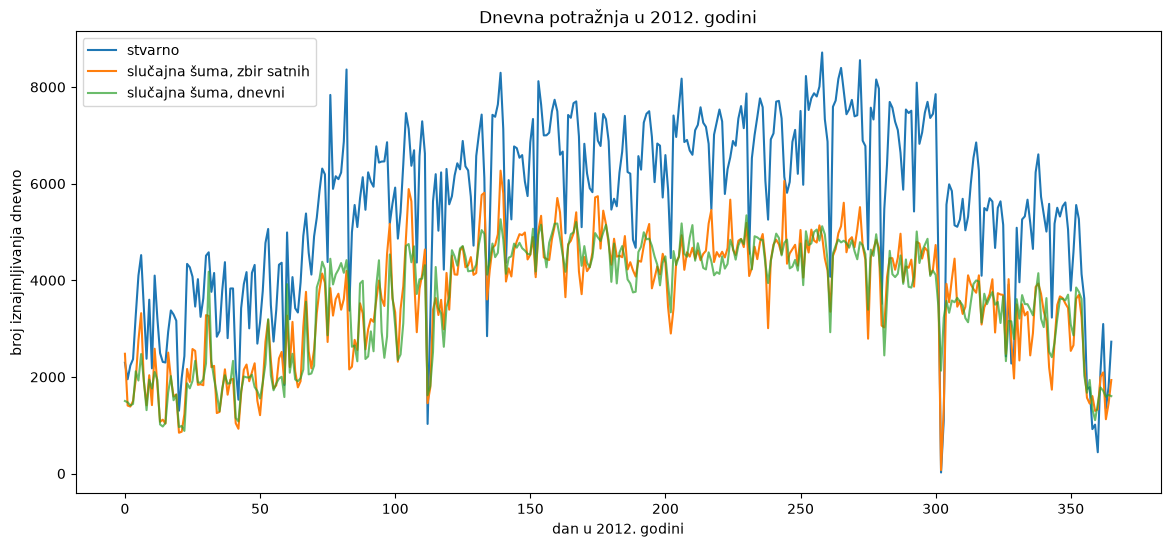

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(dnevno['stvarno'].values, label='stvarno')
plt.plot(dnevno['slučajna šuma'].values, label='slučajna šuma, zbir satnih')
plt.plot(y_dan_predicted_forest, label='slučajna šuma, dnevni', alpha=0.7)
plt.xlabel('dan u 2012. godini')
plt.ylabel('broj iznajmljivanja dnevno')
plt.title('Dnevna potražnja u 2012. godini')
plt.legend()
plt.show()

Oba modela prate sezonski oblik, rast u proleće i pad u jesen, i reaguju na lošije vreme, ali su cele godine ispod stvarne krive. Apsolutni razmak je najmanji zimi, a najveći u mesecima najveće potražnje, a relativno je, kao i na satnom nivou, najveći na početku godine, gde je skok između 2011. i 2012. bio najveći.

## Dnevni nivo, nasumična podela

Za poređenje, ista dva dnevna modela na nasumičnoj podeli, sa polovinom dana
u treningu i polovinom u testu.

In [23]:
indeksi_trening, indeksi_test = model_selection.train_test_split(np.arange(len(dan)),
                                                                 test_size=0.5,
                                                                 random_state=7)

In [24]:
scaler_dan_n = preprocessing.StandardScaler()
scaler_dan_n.fit(X_dan.iloc[indeksi_trening])

model_linear_dan_n = linear_model.LinearRegression()
model_linear_dan_n.fit(scaler_dan_n.transform(X_dan.iloc[indeksi_trening]), y_dan[indeksi_trening])

model_forest_dan_n = ensemble.RandomForestRegressor(n_estimators=model_forest.n_estimators,
                                                    max_depth=model_forest.max_depth,
                                                    random_state=7)
model_forest_dan_n.fit(X_dan.iloc[indeksi_trening], y_dan[indeksi_trening])

RandomForestRegressor(n_estimators=50, random_state=7)

In [25]:
oceni(y_dan[indeksi_test],
      model_linear_dan_n.predict(scaler_dan_n.transform(X_dan.iloc[indeksi_test])),
      'linearna regresija, dnevni, nasumična')
oceni(y_dan[indeksi_test],
      model_forest_dan_n.predict(X_dan.iloc[indeksi_test]),
      'slučajna šuma, dnevni, nasumična')
print()

linearna regresija, dnevni, nasumična  MAE   604.5  RMSE   813.6  R2  0.829  odstupanje    -27.0
slučajna šuma, dnevni, nasumična       MAE   532.6  RMSE   742.3  R2  0.857  odstupanje     +5.9



Na nasumičnoj podeli dnevna šuma ima grešku oko 530 bicikala dnevno i koeficijent determinacije 0.86, a linearna regresija 0.83. Isti modeli na hronološkoj podeli imaju grešku četiri puta veću. Na dnevnom nivou je razlika između dve podele još drastičnija nego na satnom, jer je nivo potražnje jedino što dnevni model treba da pogodi, a upravo to hronološka podela sakriva.

# Povremeni i registrovani korisnici

U analizi smo videli da su povremeni i registrovani korisnici dve različite populacije sa različitim dnevnim profilom. Proveravamo da li se bolje predviđaju odvojeno. Obučavamo dve slučajne šume, jednu za casual i jednu za registered, sa istim metaparametrima kao za ukupnu potražnju.

In [26]:
y_casual = sat['casual'].values
y_registered = sat['registered'].values

model_forest_casual = ensemble.RandomForestRegressor(n_estimators=model_forest.n_estimators,
                                                     max_depth=model_forest.max_depth,
                                                     random_state=7)
model_forest_casual.fit(X[h_trening_validacija], y_casual[h_trening_validacija])

model_forest_registered = ensemble.RandomForestRegressor(n_estimators=model_forest.n_estimators,
                                                         max_depth=model_forest.max_depth,
                                                         random_state=7)
model_forest_registered.fit(X[h_trening_validacija], y_registered[h_trening_validacija])

RandomForestRegressor(n_estimators=50, random_state=7)

In [27]:
y_test_predicted_casual = model_forest_casual.predict(x_test)
y_test_predicted_registered = model_forest_registered.predict(x_test)

oceni(y_casual[h_test], y_test_predicted_casual, 'povremeni korisnici')
oceni(y_registered[h_test], y_test_predicted_registered, 'registrovani korisnici')
print()
oceni(y_test, y_test_predicted_casual + y_test_predicted_registered, 'zbir dva modela')
oceni(y_test, predvidjanja['slučajna šuma'], 'jedan model za ukupnu potražnju')
print()

povremeni korisnici                    MAE    19.1  RMSE    33.9  R2  0.646  odstupanje    -11.1
registrovani korisnici                 MAE    76.4  RMSE   107.9  R2  0.622  odstupanje    -70.6

zbir dva modela                        MAE    91.5  RMSE   127.9  R2  0.625  odstupanje    -81.6
jedan model za ukupnu potražnju        MAE    93.0  RMSE   129.7  R2  0.614  odstupanje    -81.2



Apsolutne greške nisu uporedive jer registrovanih korisnika ima nekoliko puta više.
Zato gledamo odstupanje u odnosu na prosek, kao i rast svake grupe iz 2011. u 2012.

In [28]:
prosek_casual = y_casual[h_test].mean()
prosek_registered = y_registered[h_test].mean()

print('prosek po satu u 2012, povremeni:    %6.1f' % prosek_casual)
print('prosek po satu u 2012, registrovani: %6.1f' % prosek_registered)
print()
print('relativno odstupanje, povremeni:     %+6.1f %%'
      % (100 * np.mean(y_test_predicted_casual - y_casual[h_test]) / prosek_casual))
print('relativno odstupanje, registrovani:  %+6.1f %%'
      % (100 * np.mean(y_test_predicted_registered - y_registered[h_test]) / prosek_registered))
print()
print('rast 2012/2011, povremeni:     %.2f' % (prosek_casual / y_casual[h_trening_validacija].mean()))
print('rast 2012/2011, registrovani:  %.2f' % (prosek_registered / y_registered[h_trening_validacija].mean()))

prosek po satu u 2012, povremeni:      42.7
prosek po satu u 2012, registrovani:  192.0

relativno odstupanje, povremeni:      -25.9 %
relativno odstupanje, registrovani:   -36.8 %

rast 2012/2011, povremeni:     1.49
rast 2012/2011, registrovani:  1.67


Zbir dva odvojena modela je za oko jedan i po bicikl po satu bolji od jednog modela za ukupnu potražnju, što je mala razlika. Odvojeno modelovanje ne rešava glavni problem.

Zanimljivija je razlika u odstupanju. Model za povremene korisnike potcenjuje za oko četvrtinu, a model za registrovane za više od trećine. To se slaže sa rastom: broj registrovanih korisnika je porastao 1.67 puta, a povremenih 1.49 puta. Rast sistema je došao pre svega kroz nove registrovane korisnike, i upravo taj deo modeli najviše promašuju.

# Odakle dolazi sistematsko odstupanje

Svi modeli potcenjuju potražnju u 2012. za sličan iznos, bez obzira na vrstu modela
i nivo agregacije. Proveravamo da li je uzrok u podacima: modeli nikada nisu videli
nijedan podatak iz 2012, pa atribut yr u treningu ima uvek istu vrednost.

Obučavamo slučajnu šumu na 2011. godini proširenoj sa prvih nekoliko meseci 2012.
i ocenjujemo je uvek na istom periodu, od jula do decembra 2012. Tako vidimo koliko
se odstupanje smanjuje kada model vidi makar deo nove godine.

Ovo je dijagnostički eksperiment i ne ulazi u poređenje modela, jer koristi deo test
godine za obučavanje. Zato ga ocenjujemo isključivo na drugom polugodištu, koje nijedan
od ovih modela nije video.

In [29]:
test_drugo_polugodiste = ((sat['yr'] == 1) & (sat['mnth'] > 6)).values

brojevi_meseci = [0, 1, 3, 6]
rezultati_rast = []

for meseci in brojevi_meseci:
    maska_trening = ((sat['yr'] == 0) | ((sat['yr'] == 1) & (sat['mnth'] <= meseci))).values

    model = ensemble.RandomForestRegressor(n_estimators=model_forest.n_estimators,
                                           max_depth=model_forest.max_depth,
                                           random_state=7)
    model.fit(X[maska_trening], y[maska_trening])

    y_predicted = model.predict(X[test_drugo_polugodiste])
    rezultati_rast.append(oceni(y[test_drugo_polugodiste], y_predicted,
                                '2011 + %d meseci 2012' % meseci))

2011 + 0 meseci 2012                   MAE    98.6  RMSE   137.1  R2  0.610  odstupanje    -86.7
2011 + 1 meseci 2012                   MAE    98.2  RMSE   135.6  R2  0.619  odstupanje    -82.2
2011 + 3 meseci 2012                   MAE    74.4  RMSE   104.5  R2  0.774  odstupanje    -42.0
2011 + 6 meseci 2012                   MAE    64.5  RMSE    91.6  R2  0.826  odstupanje    -38.3


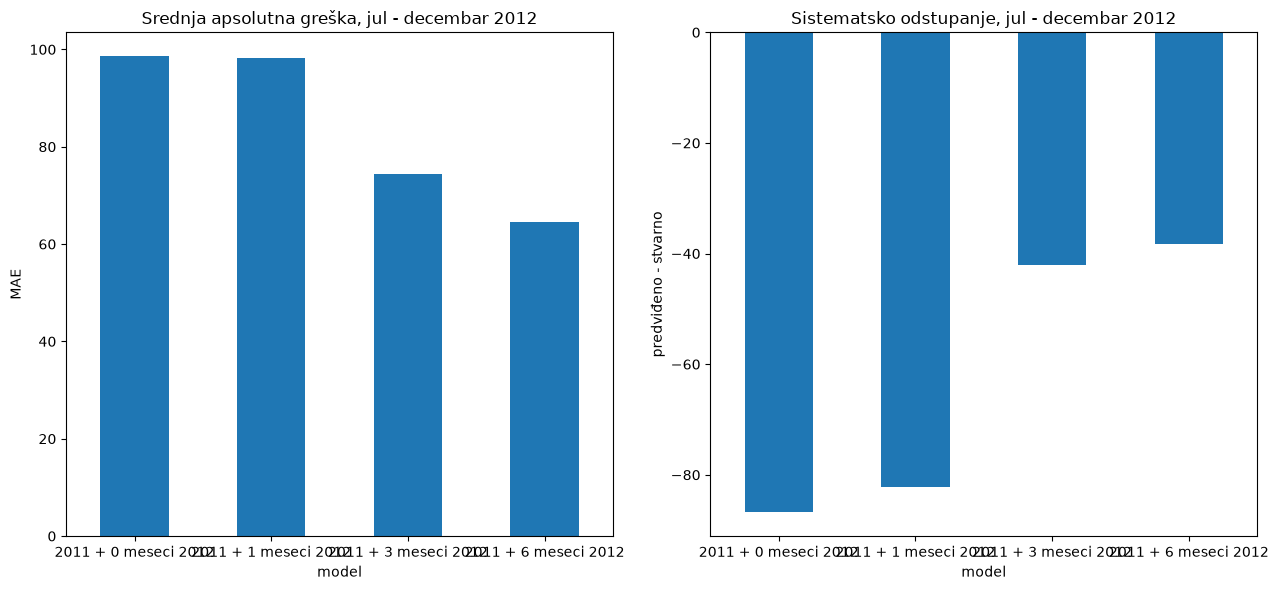

In [30]:
tabela_rast = pd.DataFrame(rezultati_rast).set_index('model')

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

tabela_rast['MAE'].plot(kind='bar', ax=ax[0], rot=0)
ax[0].set_title('Srednja apsolutna greška, jul - decembar 2012')
ax[0].set_ylabel('MAE')

tabela_rast['odstupanje'].plot(kind='bar', ax=ax[1], rot=0)
ax[1].set_title('Sistematsko odstupanje, jul - decembar 2012')
ax[1].set_ylabel('predviđeno - stvarno')

plt.tight_layout()
plt.show()

Sa samo januarom 2012. u treningu rezultat se skoro ne menja, jer je januar mesec sa
najmanjom potražnjom i model iz njega ne može da nauči novi nivo. Sa tri meseca
odstupanje pada sa -87 na -42, a greška sa 99 na 74 bicikla. Sa pola godine koeficijent
determinacije dostiže 0.83, što je blizu vrednosti koju smo videli na nasumičnoj podeli.

Dakle, sistematsko odstupanje nije mana modela nego posledica podataka. Skup sadrži
samo dve godine, a potražnja između njih raste. Model može da nauči rast tek kada
u podacima za obučavanje vidi bar nekoliko meseci sa novim nivoom.

# Čuvanje rezultata

In [31]:
tabela_dan.to_csv('../models/07_rezultati_dnevni.csv')
tabela_rast.to_csv('../models/07_rezultati_rast.csv')

print('sačuvano')

sačuvano


# Ograničenja projekta

1. Skup pokriva samo dve godine i jedan grad. Zaključci o rastu potražnje se oslanjaju
   na jednu promenu nivoa, iz 2011. u 2012, i ne mogu se uopštiti na druge sisteme.

2. Vremenski atributi u skupu su izmereni, ne prognozirani. U stvarnoj primeni model
   bi radio sa prognozom, koja ima sopstvenu grešku, pa bi rezultati bili nešto lošiji.

3. Metaparametri su birani na jednom skupu za validaciju, poslednjih dvadeset procenata
   2011 godine. Za pouzdaniji izbor bi trebalo koristiti unakrsnu validaciju
   za vremenske serije sa više podela.

4. Neuronska mreža nije obučena više puta sa različitim semenima, pa je prednost od pet
   bicikala u odnosu na slučajnu šumu manja od razlike koju bi mogla da napravi
   slučajnost obučavanja.

5. Nisu ispitani atributi koji opisuju prethodne sate, na primer potražnja u istom satu
   prethodnog dana. Takvi atributi bi modelu dali informaciju o trenutnom nivou i verovatno
   bi znatno smanjili sistematsko odstupanje, ali izlaze iz okvira ovog projekta.

# Zaključci

1. Na satnom nivou, na hronološkoj podeli, najbolji model je potpuno povezana neuronska
   mreža sa greškom od 88 bicikala po satu i koeficijentom determinacije 0.66, a odmah
   iza nje slučajna šuma sa 93 i 0.61. Linearni modeli i metod najbližih suseda su lošiji
   od trivijalne osnove, proseka po satu i tipu dana.

2. Linearni modeli gube od trivijalne osnove jer ne mogu da izraze interakciju sata i tipa dana, a metod najbližih suseda zato što prosek suseda iz 2011. ne dostiže nivo iz 2012. Za ovaj problem je važnija vrsta modela nego podešavanje metaparametara.

3. Na dnevnom nivou zbir satnih predviđanja slučajne šume je bolji od modela obučenih
   direktno na dnevnim podacima. Dnevni modeli imaju manje instanci i manje informacija.

4. Svi modeli, na oba nivoa, potcenjuju potražnju u 2012. za oko trećinu. Odstupanje
   dolazi iz podataka: sistem je porastao, a modeli su obučeni pre rasta. Kada model vidi
   pola nove godine, koeficijent determinacije raste sa 0.61 na 0.83.

5. Rast je došao pre svega kroz registrovane korisnike, pa se oni i najviše potcenjuju.
   Odvojeno modelovanje dve grupe daje malo poboljšanje, ali ne rešava problem nivoa.

6. Nasumična podela precenjuje kvalitet svih modela, na satnom nivou dva do tri puta
   po grešci, a na dnevnom četiri puta. Za podatke koji se menjaju kroz vreme
   podela mora biti hronološka, inače rezultat ne govori ništa o budućem ponašanju modela.